# Normals and curvatures

This notebook focuses on the estimation of normals and curvatures in 3D pointclouds. These geometric properties **describe the local orientation and shape of the underlying surface** and provide more useful geometric information than point coordinates alone. They are widely used in 3D processing tasks such as visualization, segmentation, surface reconstruction or registration.

This notebook presents common methods for estimating normals and curvatures, primarily through local surface fitting techniques.

In [1]:
# Necessary imports
import sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy.spatial import KDTree, Delaunay
from scipy.sparse import dok_matrix
from scipy.sparse.csgraph import minimum_spanning_tree, breadth_first_order

sys.path.append("./utils")
from manip_utils import orthonormal_basis_from_w

# Load our bunny pointcloud
data = np.loadtxt("./data/stanford_bunny_custom.xyz")
points = data[:, :3]
ref_normals = data[:, 3:6]
H_ref = data[:, -2]
K_ref = data[:, -1]
# Build KDTree for neighbor search
kdtree = KDTree(points)


## Normals

**A normal is a vector associated with each point that is perpendicular to the underlying surface it samples**. By convention, **normals are oriented outward from the surface** and are typically represented as unit vectors. While some acquisition systems provide normals directly, they are most often estimated from the point coordinates.

### Tangent plane estimation

The most common approach for estimating normals is based on **tangent plane estimation**, where the underlying surface is locally approximated by a plane. For each point, a plane is fitted in a least-squares sense to a neighborhood composed of the point and its nearest neighbors. The normal is then approximated by the normal vector of the fitted plane \cite{hoppe1992surface}.

For each point $p_i$ of the pointcloud:

1. Query the $k$-nearest neighbors of $p_i$ and form the neighborhood $N_{i}$.

2. Compute the covariance matrix $cov_{i}$ of this neighborhood.

3. Compute the eigenvalues $\lambda_{1}^{i} \geq \lambda_{2}^{i} \geq \lambda_{3}^{i}$ and eigenvectors $(\nu_{1}^{i}, \nu_{2}^{i}, \nu_{3}^{i})$ of $cov_{i}$.

4. Estimate **the normal as the eigenvector associated with the smallest eigenvalue**:
\begin{equation*}
    n_{i} \pm \nu_{3}^{i}
\end{equation*}

Indeed, the eigenvector $\nu_{3}^{i}$ corresponds to the direction of minimum variation in the neighborhood, which is assumed to be orthogonal to the local surface. Note that tangent plane estimation does not determine the orientation of the normals, it only provides a direction (i.e., $\pm n$). A separate orientation step is required, as discussed later.

The covariance matrix is given by:
\begin{equation*}
    cov_{i} = \sum_{p_{j} \in N_{i}} (p_{j} - c_{i}) \cdot (p_{j} - c_{i})^{T}
\end{equation*}

where $c_{i}$ is the centroid of the neighborhood:
\begin{equation*}
    c_{i} = \frac{1}{|N_{i}|} \sum_{p_{j} \in N_{i}} p_{j}
\end{equation*}

The fitting process is here considered in the sense of least squares, and the fitting error is given directly by $\lambda_{3}$.

The implementation below is fully vectorized, which significantly reduces execution time compared to a point-by-point implementation, at the cost of increased memory usage since all neighborhoods and covariance matrices must be stored in memory at once.

In [2]:
def compute_normals(points, neighbor_finder):
    """Normals by tangent plane estimation using k-nearest neighbors"""
    
    # Neighborhoods
    inds = neighbor_finder(points) # (N, k)
    k = inds.shape[-1]
    neighbors = points[inds] # (N, k, 3)
    # Eigenvalues from covariance matrix
    neighbors -= neighbors.mean(axis=1, keepdims=True) # center in-place
    cov = (neighbors.transpose(0, 2, 1) @ neighbors) / k  # (N, 3, 3)
    eigenvalues, eigenvectors = np.linalg.eigh(cov) # (N, 3, 3)
    # Normals and residuals
    normals = eigenvectors[:,:,0] # already normalized
    residuals = eigenvalues[:, 0]
    
    return normals, residuals


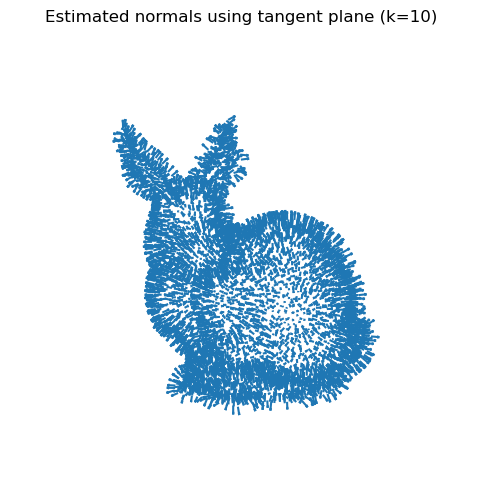

In [3]:
# Estimate normals using k-neighborhoods
k_normals = 10
neighbor_finder = lambda points: kdtree.query(points, k_normals)[1]
normals, residuals = compute_normals(points, neighbor_finder)

# Visualize the pointcloud and normals
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.quiver(points[:, 0], points[:, 1], points[:, 2],
        normals[:, 0], normals[:, 1], normals[:, 2],
        length=5.) # make normals appear a little bit larger
ax.set_box_aspect([1, 1, 1])
ax.view_init(10, 60)
ax.set_axis_off()
ax.set_title(f"Estimated normals using tangent plane (k={k_normals})")
plt.show()


**The accuracy of tangent plane estimation strongly depends on the neighborhood used to fit the plane**. Small neighborhoods better capture local surface geometry but are more sensitive to noise. Larger neighborhoods are more robust to noise, but may smooth out geometric details and violate the local planarity assumption. Choosing the neighborhood size therefore involves a trade-off between locality and robustness.

In practice, the neighborhood is usually defined either by the $k$-nearest neighbors or by all points within a radius $r$. A common starting point is $k = 10$, which can then be adjusted according to point density, noise level, and surface complexity.

To illustrate the influence of $k$, normals are estimated for several neighborhood sizes and compared with the reference normals (derived from the original bunny mesh). At this stage, only the normal directions are evaluated, regardless of their orientation. The resulting angular error distributions are summarized in the boxplot below.

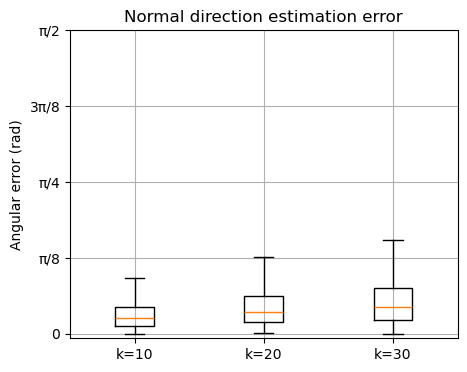

In [4]:
# Compute error between estimated and reference normals for differnt k
k_values = [10, 20, 30]
normal_errors_k = []
for k in k_values:
    neighbor_finder = lambda points: kdtree.query(points, k)[1]
    normals_k, _ = compute_normals(points, neighbor_finder)
    error_k = np.abs(np.sum(normals_k * ref_normals, axis=1))
    error_k = np.clip(error_k, -1.0, 1.0)
    error_k = np.arccos(error_k)
    normal_errors_k.append(error_k)

# Plot angular error
fig, ax = plt.subplots(figsize=(5, 4))
ax.boxplot(
    normal_errors_k,
    tick_labels=[f"k={k}" for k in k_values],
    showfliers=False
)
ax.set_ylabel("Angular error (rad)")
ax.set_yticks(
    [0., np.pi/8, np.pi/4, 3*np.pi/8, np.pi/2],
    ["0", "π/8", "π/4", "3π/8", "π/2"]
)
ax.set_title("Normal direction estimation error")
ax.grid(True)
plt.show()

The quality of the local plane fit can be assessed from the smallest eigenvalue $\lambda_{3}$​, which measures the variation of the points in the normal direction. A small value indicates that the neighborhood is close to planar, while larger values suggest either noise or significant surface curvature. However, $\lambda_{3}$ is scale-dependant. A scale-independent measure is obtained by normalizing $\lambda_{3}$ by the sum of the eigenvalues, a quantity known as *surface variation* (see next section on curvatures)

The residuals highlight regions where the tangent plane approximation is less valid. As expected, larger residuals are observed near highly curved areas such as the ears of the bunny below.

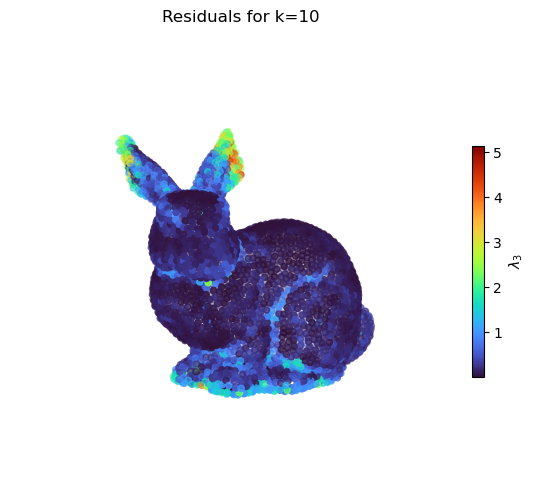

In [5]:
# Visualize residuals
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
im = ax.scatter(points[:, 0], points[:, 1], points[:, 2],
                c=residuals, cmap="turbo")
cbar = fig.colorbar(im, ax=ax, shrink=0.5, pad=0)
cbar.set_label("$\\lambda_{3}$")
ax.set_box_aspect([1, 1, 1])
ax.view_init(elev=10, azim=60)
ax.set_axis_off()
ax.set_title(f"Residuals for k={k_normals}")
plt.show()


### Orientation with Riemannian Graph

The tangent plane estimation procedure only determines the normal direction up to a sign (i.e., $\pm n$). As a result, neighboring points may have normals pointing in opposite directions, producing inconsistent orientations across the surface.

To resolve this ambiguity, it is commonly assumed that the pointcloud is sufficiently dense and that the underlying surface is locally smooth. Under these conditions, tangent planes estimated at two nearby points $p_{i}$​ and $p_{j}$​ are expected to be nearly parallel. Consequently, their associated normals should satisfy:
\begin{equation*}
    n_{i} \cdot n_{j} \approx \pm 1
\end{equation*}

Two normals are considered consistently oriented when:
\begin{equation*}
    n_{i} \cdot n_{j} > 0
\end{equation*}

Otherwise, one of them must be flipped.

The main difficulty is determining which pairs of neighboring points should be compared. This is usually addressed by **finding a path through neighboring points that minimizes variations in normal directions**, using a *Riemannian Graph*. In this graph, vertices correspond to points, edges connect nearby points, and edge weights are derived from the angle between neighboring normals. **The desired path is obtained by extracting the minimum spanning tree of the graph**, which connects all points while minimizing the total variation in normal directions. Starting from a chosen seed point, the tree is then traversed and normals are flipped when necessary to enforce a consistent orientation over the entire pointcloud.

The procedure can be summarized as follows:

1. Compute the Euclidean Minimum Spanning Tree (EMST), which connects all points while minimizing the total edge length.

2. Add edges to the EMST to connect each point to its $k$-nearest neighbors to form the *Riemannian Graph*.

3. Define edge weights as: 
\begin{equation*}
    e_{ij} = 1 - |n_i \cdot n_j|
\end{equation*}

4. Extract the minimum spanning tree of the *Riemannian Graph*.

5. Select an initial point and orient its normal (for example make the point with the highest $z$ coordinate pointing towards $z^{+}$).

6. Traverse the tree and flip normal $n_{j}$ whenever $n_{i} \cdot n_{j} < 0$.

Note that the EMST is a subgraph of the Delaunay triangulation. Computing the Delaunay triangulation is therefore an efficient way of obtaining the EMST.

The implementation proposed below mostly relies on `scipy` routines for nearest-neighbor search, Delaunay triangulation, minimum spanning tree extraction, and graph traversal. Graphs are represented as sparse matrices, where the value at position $(i, j)$ corresponds to the weight of the edge connecting vertices $v_{i}$ and $v_{j}$.

In [6]:
def orient_normals(points, normals, neighbor_finder):
    """Orient normals using a Riemannian Minimum Spanning Tree (RMST) approach."""
    
    normals = normals.copy()

    # Create graph (adjacency matrix)
    n_points = len(points)
    riemannian_graph = dok_matrix((n_points, n_points), dtype=np.float32)

    # Compute the Euclidean graph using Delaunay triangulation
    tri = Delaunay(points)
    indptr, indices = tri.vertex_neighbor_vertices
    for i in range(n_points) :
        neighbors = indices[indptr[i]:indptr[i+1]]
        dists = np.linalg.norm(points[i] - points[neighbors], axis=1)
        riemannian_graph[i, neighbors] = dists
    
    # Compute the minimum spanning tree of the Euclidean graph (EMST)
    riemannian_graph = minimum_spanning_tree(riemannian_graph, overwrite=True)
    riemannian_graph = riemannian_graph.todok() # faster manipulation with DOK

    # Add k-nearest neighbors to the Riemannian graph
    neighbors = neighbor_finder(points) # point itself is included
    neighbors = neighbors[:, 1:] # Remove the point itself
    for i, nbrs in enumerate(neighbors):
        riemannian_graph[i, nbrs] = 1.

    # Weight the edges of the Riemannian graph according to normal similarity
    for (i, j) in riemannian_graph.keys():
        riemannian_graph[i, j] = 1 - np.abs(normals[i] @ normals[j]) + 1e-6

    # Compute the minimum spanning tree of the Reimannian graph
    riemannian_graph = minimum_spanning_tree(riemannian_graph, overwrite=True)

    # Choose the point with the highest z-coordinate as the root
    root_index = np.argmax(points[:, 2])
    # and orient its normal upwards
    if normals[root_index, 2] < 0:
        normals[root_index] *= -1

    # Propagate normals through the MST
    node_array, predecessors = breadth_first_order(
        riemannian_graph, root_index, directed=False, return_predecessors=True
    )
    node_array = node_array[1:] # Exclude the root node from processing
    for current in node_array:
        previous = predecessors[current]
        # Ensure normal consistency
        if normals[current] @ normals[previous] < 0:
            normals[current] *= -1 

    return normals


The orientation procedure is now applied to the estimated normals. Since the sign ambiguity has been resolved, the angular error is computed without taking the absolute value of the dot product.

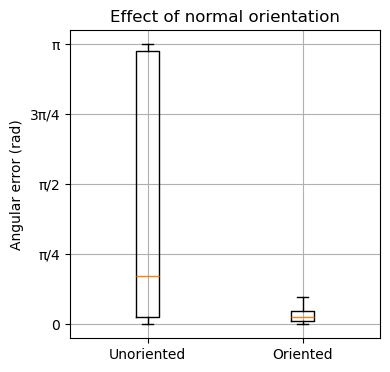

In [7]:
# Orient normals (reuse k=10)
neighbor_finder = lambda points: kdtree.query(points, k_normals)[1]
oriented_normals = orient_normals(points, normals, neighbor_finder)

# Estimate angular error between estimated, oriented and reference normals
normal_orientation_errors = []
for n in [normals, oriented_normals]:
    error_orient = np.sum(n * ref_normals, axis=1) # no np.abs here
    error_orient = np.clip(error_orient, -1.0, 1.0)
    error_orient = np.arccos(error_orient)
    normal_orientation_errors.append(error_orient)

# Plot angular error between estimated normals and reference normals
fig, ax = plt.subplots(figsize=(4, 4))
ax.boxplot(
    normal_orientation_errors,
    tick_labels=["Unoriented", "Oriented"],
    showfliers=False
)
ax.set_ylabel("Angular error (rad)")
ax.set_yticks(
    [0., np.pi/4, np.pi/2, 3*np.pi/4, np.pi],
    ["0", "π/4", "π/2", "3π/4", "π"]
)
ax.set_title("Effect of normal orientation")
ax.grid(True)
plt.show()
            

## Curvatures

**Curvature measures how the underlying surface bends around a point**. Unlike normals, which only describe surface orientation, curvatures characterize local shape and distinguish between flat, convex, concave, and saddle-like regions.

Most curvature measures come from differential geometry and the study of the local behavior of smooth surfaces. From this viewpoint, any sufficiently smooth surface admits at each point a tangent plane and an associated normal vector. Curvature expresses how the surface deviates from this tangent plane when moving in different tangent directions. **Principal curvatures $(\kappa_{1}, \kappa_{2})$ correspond to the maximum and minimum bending of the surface and are associated with two orthogonal directions $(t_{1}, t_{2})$, called principal directions**.

Several commonly used curvature measures are derived from the principal curvatures. Among them, the most important are the **Gaussian curvature $K$ and the mean curvature $H$**, defined by:
\begin{equation*}
K = \kappa_{1} . \kappa_{2} \qquad H = \frac{\kappa_{1} + \kappa_{2}}{2}
\end{equation*}

Gaussian curvature characterizes the local shape of the surface (saddle, planar, or dome-like), while mean curvature measures its average bending and distinguishes convex from concave regions. Together, they allow a local classification of surface shape, described below. Note that the distinction between a ridge and a valley, or between a peak and a pit, is entirely determined by the orientation of the surface.

|       | $K<0$         | $K=0$  | $K>0$        |
|:------|:--------------|:-------|:-------------|
| $H<0$ | Saddle ridge  | Ridge  | Peak         |
| $H=0$ | Minimal       | Plane  | (impossible) |
| $H>0$ | Saddle valley | Valley | Pit          |

The principal curvatures may also be recovered from $K$ and $H$:
\begin{equation*}
    \kappa_{1}, \kappa_{2} = H \pm \sqrt{H^{2} - K}
\end{equation*}

Many other descriptors are also derived from the principal curvatures. Among these descriptors, the **shape index** $S$ and **curvedness** $C$ form a particularly influential pair \cite{koenderink1992surface}. The first provides a continuous description of the local shape type (e.g., dome, ridge, saddle, valley), while the second measures the overall manigitude of bending. Together, they provide an intuitive and scale-independent description of local surface geometry, making them useful for tasks such as segmentation, classification, and geometric feature detection.
\begin{equation*}
S = \frac{2}{\pi} \arctan(\frac{\kappa_{2} + \kappa_{1}}{\kappa_{2} - \kappa_{1}}) \qquad C = \sqrt{\frac{\kappa_{1}^{2} + \kappa_{2}^{2}}{2}}
\end{equation*}

In differential geometry theory, principal curvatures $\kappa_{1}$ and $\kappa_{2}$ are obtained from the *Shape operator* (also called the *Weingarten map*), which describes how the surface normal varies along tangent directions. This requires constructing a local tangent frame, computing the first and second fundamental forms, assembling the shape operator, and diagonalizing it to obtain the principal curvatures and their directions.

In practice, these **differential geometry tools are not directly applicable to pointclouds, which are noisy discrete samples of an underlying surface**. As a consequence, curvatures cannot be computed exactly and must instead be estimated from local neighborhoods.

To bridge this gap, a variety of **estimation techniques** have been proposed, each offering a different compromise between robustness, computational cost and adherence to the principles of differential geometry. The following sections present some of the most common approaches.

### PCA-based surface variation

As previously discussed, curvature is related to how a surface bends around a point. In a pointcloud, one way to estimate this bending is to measure how much the neighboring points deviate from the local tangent plane.

The previous section showed that a tangent plane can be estimated from the covariance matrix of a local neighborhood. The eigenvalues of this matrix describe the variation of the points along the principal directions of the neighborhood. In particular, the smallest eigenvalue $\lambda_{3}$​ measures the variation along the normal direction and corresponds to the residual of the tangent plane fit.

This leads to a commonly used curvature indicator, called *surface variation* or *curvature change*, defined as the **ratio between this smallest eigenvalue and the total variance of the neighborhood** \cite{pauly2002efficient}:
\begin{equation*}
    C_{\lambda} = \frac{\lambda_3}{\lambda_1 + \lambda_2 + \lambda_3}
\end{equation*}

Higher surface variation indicates a less planar neighborhood. Its value ranges from $0$ to $1/3$, where $0$ corresponds to a perfectly planar neighborhood, and $1/3$ corresponds to an isotropic distribution.

It should be noted that surface variation does not provide the principal curvatures $\kappa_{1}$ and $\kappa_{2}$, nor any direct estimate of Gaussian or mean curvature. Instead, it acts as **a simple proxy for the overall curvature magnitude**. Because it only requires the covariance eigenvalues already computed for normal estimation, it is inexpensive to evaluate and widely used in large-scale pointcloud processing. As with normal estimation, its accuracy depends strongly on the neighborhood size and the level of noise.

In [8]:
def compute_curvature_pca(points, neighbor_finder):
    """Compute curvature change indicator using PCA."""

    # Neighborhoods
    inds = neighbor_finder(points) # (N, k)
    k = inds.shape[-1]
    neighbors = points[inds] # (N, k, 3)
    # Eigenvalues from covariance matrix
    neighbors -= neighbors.mean(axis=1, keepdims=True) # center in-place
    cov = (neighbors.transpose(0, 2, 1) @ neighbors) / k  # (N, 3, 3)
    eigenvalues = np.linalg.eigvalsh(cov) # (N, 3, 3)
    
    return eigenvalues[:, 0] / np.sum(eigenvalues, axis=1)


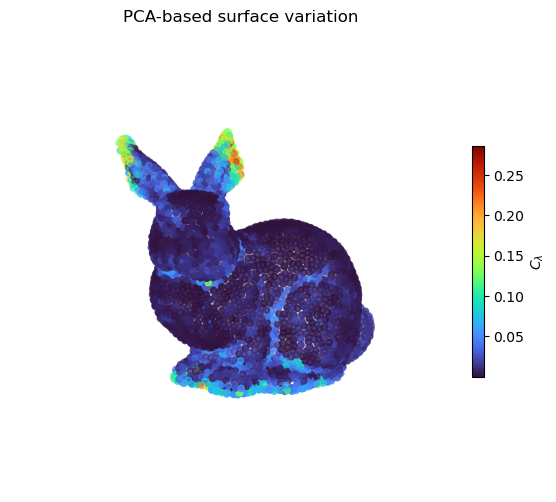

In [9]:
# Compute curvature change indicator
neighbor_finder = lambda point: kdtree.query(point, k=10)[1]
curvature_change = compute_curvature_pca(points, neighbor_finder)

# Visualize curvature change indicator
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
im = ax.scatter(points[:, 0], points[:, 1], points[:, 2],
                c=curvature_change, cmap="turbo")
cbar = fig.colorbar(im, ax=ax, shrink=0.5, pad=0)
cbar.set_label("$C_{\\lambda}$")
ax.view_init(10, 60)
ax.set_box_aspect([1, 1, 1])
ax.set_axis_off()
ax.set_title("PCA-based surface variation")
plt.show()


### Local surface fitting

Another common strategy for estimating curvature on pointclouds is to **locally approximate the underlying smooth surface by fitting a simple surface patch**, and then **apply standard differential‑geometry formulas directly** to the fitted surface. This approach is appealing because it provides direct estimates of quantities such as principal, Gaussian, and mean curvatures. It is widely used in practice and performs particularly well on dense and smooth pointclouds. However, its accuracy depends strongly on the choice of neighborhood and it can be sensitive to noise.

Several types of surface models can be used. The choice generally involves a trade-off between simplicity and the ability to represent complex local geometry. The next subsections present two common approaches based on parametric and implicit surface fitting.

#### Parametric surfaces

In 3D space, parametric surfaces express the coordinates of surface points as functions of two parameters:

\begin{equation*}
r(u, v) = (x(u,v), y(u,v), z(u,v))
\end{equation*}

The generic process for estimating curvature from a parametric surface consists of computing its first- and second-order derivatives, deriving the associated fundamental forms, and extracting the principal curvatures from the corresponding shape operator.

The required derivatives are:

\begin{equation*}
    r_{u} = \frac{\partial r}{\partial u}
    \quad
    r_{v} = \frac{\partial r}{\partial v}
    \quad
    r_{uv} = \frac{\partial^{2} r}{\partial u \partial v}
    \quad
    r_{uu} = \frac{\partial^{2} r}{\partial^{2} u}
    \quad
    r_{vv} = \frac{\partial^{2} r}{\partial^{2} v}
\end{equation*}

The surface normal is then given by:

\begin{equation*}
    n(u, v) = \frac{r_{u} \times r_{v}}{\lVert r_{u} \times r_{v} \rVert}
\end{equation*}

The first and second fundamental forms are constructed from these quantities:

\begin{equation*}
    I = E du^{2} + 2F du dv + G dv^{2}
    \qquad
    II = L du^{2} + 2M du dv + N dv^{2}
\end{equation*}

where

\begin{equation*}
    E = r_{u} \cdot r_{u} = \lVert r_{u} \rVert^{2}
    \quad
    F = r_{u} \cdot r_{v}
    \quad
    G = r_{v} \cdot r_{v} = \lVert r_{v} \rVert^{2}
\end{equation*}

and 

\begin{equation*}
    L = r_{uu} \cdot n
    \quad
    M = r_{uv} \cdot n
    \quad
    N = r_{vv} \cdot n
\end{equation*}

The corresponding shape operator is:

\begin{equation*}
    P = \begin{pmatrix} E & F \\ F & G \end{pmatrix}^{-1} \begin{pmatrix} L & M \\ M & N \end{pmatrix}
\end{equation*}

Its eigenvalues correspond to the principal curvatures $(\kappa_1, \kappa_2)$, while the associated eigenvectors $(\nu_{1}, \nu_{2})$ define the principal directions in the tangent basis $(r_{u}, r_{v})$. The principal directions may then be expressed in the local tangent frame as:
\begin{equation*}
    t_{1} = \nu_{11} r_{u} + \nu_{12} r_{v}
    \qquad
    t_{2} = \nu_{21} r_{u} + \nu_{22} r_{v}
\end{equation*}

Gaussian and mean curvatures may also be computed directly from the coefficients of the first and second fundamental forms:

\begin{equation*}
    K = \frac{LN - M^2}{EG - F^2}
    \qquad
    H = \frac{EN - 2FM + GL}{2(EG - F^2)}
\end{equation*}

In practice, many types of parametric surfaces can be used. A popular choice is the *quadric surface*, which provides a simple second-order approximation of the local geometry while remaining inexpensive to fit:

\begin{equation*}
    r(u, v) = (u, v, g(u, v))
\end{equation*}

with

\begin{equation*}
    w = g(u, v) = a u^{2} + b v^{2} + c u v + d u + e v + f
\end{equation*}

Because $g$ is a second-degree polynomial, its derivatives are straightforward to compute. For example:

\begin{equation*}
    r_{u} = (1, 0, g_{u})
    \qquad
    g_{u} = 2 a u + c v + d
\end{equation*}

and

\begin{equation*}
    r_{v} = (0, 1, g_{v})
    \qquad
    g_{v} = 2 b v + c u + e
\end{equation*}

After simplification, the normal, Gaussian curvature, and mean curvature at the origin $(0, 0)$ are given by:

\begin{equation*}
    n_{0} = \frac{1}{\sqrt{d^{2} + e^{2} + 1}} (-d, -e, 1)
\end{equation*}

\begin{equation*}
    K_{0} = \frac{4ab - c^{2}}{(d^{2} + e^{2} + 1)^{2}}
    \qquad
    H_{0} = \frac{a(1 + e^{2}) + b(1 + d^{2}) - cde}{(d^{2} + e^{2} + 1)^{3/2}}
\end{equation*}

A further simplification is obtained by placing the query point at the origin and aligning its normal with the vertical axis. This corresponds to setting $d = e = f = 0$, leading to:

\begin{equation*}
    K_{0} = 4 a b - c^{2}
    \qquad 
    H_{0} = a + b
\end{equation*}

**The first challenge is to define a local coordinate system in which the query point lies at the origin and the normal is aligned with the vertical axis**. For unorganized pointclouds, this local frame is typically constructed from the tangent plane estimated by PCA in the previous section.

**The second challenge is to fit the quadric surface in this local coordinate system**. Once the neighborhood has been projected into the local frame, the coefficients are obtained by least-squares fitting.

In summary, the curvature estimation process using a parametric surface follows these steps:

1. Compute the (consistently oriented) tangent plane for each point and construct the local coordinate system (see previous section about normals).

2. Express the neighborhood in the local frame and fit the quadric surface: 
\begin{equation*}
    w = a u^{2} + b v^{2} + c u v
\end{equation*}
using least-squares.

3. Compute the Gaussian and mean curvatures using the fitted surface coefficients:
\begin{equation*}
    K_{0} = 4ab - c^{2} \qquad H_{0} = a + b
\end{equation*}

The process is illustrated below using reference normals (derived from the bunny mesh) to isolate curvature estimation errors from errors introduced during tangent plane estimation and normal orientation. The implementation is partially vectorized: all neighborhoods are queried and extracted simultaneously, while local frame construction and quadric fitting are performed independently for each point. These latter steps could be further vectorized, but at the expense of readability.

In [10]:
def compute_curvatures_parametric(points, normals, neighbor_finder):
    """Compute Gaussian and mean curvatures using a parametric fitting approach."""
    
    N, _ = points.shape
    K_0 = np.empty(N)
    H_0 = np.empty(N)

    # Neighborhoods
    inds = neighbor_finder(points) # (N, k)
    neighbors = points[inds] # (N, k, 3)
    neighbors -= points[:, None, :] # center on the query point
    
    for i in range(N):
        # Project neighbors onto the tangent plane defined by the normal at the point
        basis = orthonormal_basis_from_w(normals[i])
        projected_neighbors = (basis @ neighbors[i].T).T
        # Fit a local quadratic patch to the projected neighbors
        # w = a.u² + b.v² + c.u.v
        A = np.column_stack((
            projected_neighbors[:, 0]**2, # u²
            projected_neighbors[:, 1]**2, # v²
            projected_neighbors[:, 0] * projected_neighbors[:, 1], # u.v
        ))
        heights = projected_neighbors[:, 2] # w
        coeffs, *_ = np.linalg.lstsq(A, heights, rcond=None)
        a, b, c = coeffs
        # Compute Gaussian and Mean curvatures from the fitted coefficients
        K_0[i] = 4*a*b - c**2
        H_0[i] = a + b
        
    return K_0, H_0

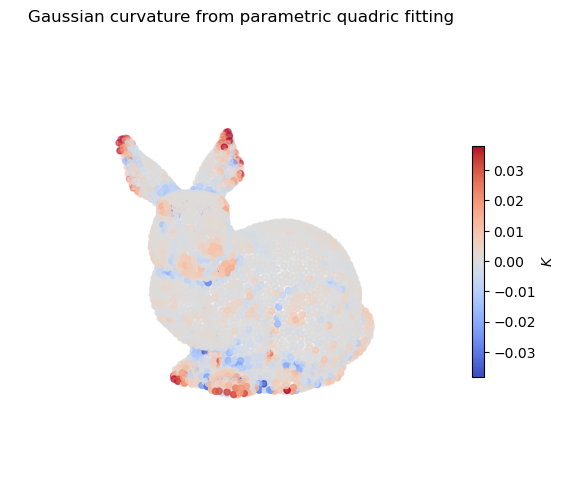

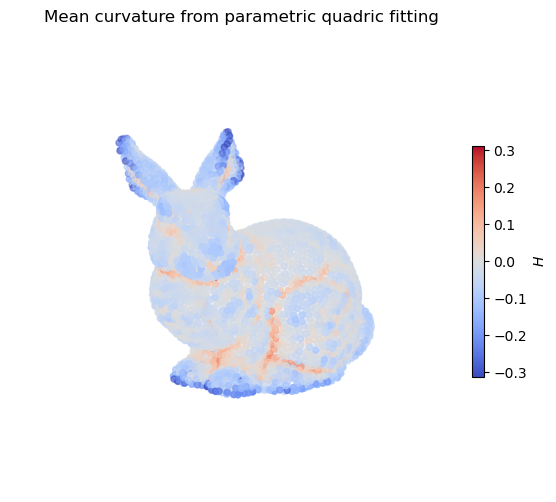

In [11]:
# Estimate curvatures using the parametric fitting approach
neighbor_finder = lambda points: kdtree.query(points, k=12)[1]
K_parametric, H_parametric = compute_curvatures_parametric(
    points, 
    ref_normals, # instead of estimated normals
    neighbor_finder
)

# Visualize curvatures
# Use reference values H_ref and K_ref for scales
ref_norms_k = {
    "Gaussian": matplotlib.colors.TwoSlopeNorm(
        vmin = -np.percentile(np.abs(K_ref), 99),
        vcenter = 0.,
        vmax = np.percentile(np.abs(K_ref), 99)
    ),
    "Mean": matplotlib.colors.TwoSlopeNorm(
            vmin = -np.percentile(np.abs(H_ref), 99),
            vcenter = 0.,
            vmax = np.percentile(np.abs(H_ref), 99)
    )
}
# Plot mean and Gaussian curvatures
for curvature_type, unit, values in [
        ("Gaussian", "$K$", K_parametric), 
        ("Mean", "$H$", H_parametric)
    ]:
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    p = ax.scatter(points[:, 0], points[:, 1], points[:, 2],
                   c=values, cmap="coolwarm", norm=ref_norms_k[curvature_type])
    cbar = fig.colorbar(p, shrink=0.5, pad=0)
    cbar.set_label(unit)
    ax.set_title(f"{curvature_type} curvature from parametric quadric fitting")
    ax.set_box_aspect([1, 1, 1])
    ax.set_axis_off()
    ax.view_init(10, 60)
    plt.show()

#### Implicit surfaces

3D implicit surfaces represent the geometry as the zero‑level set of a scalar field, such as:

\begin{equation*}
F(x, y, z) = 0
\end{equation*}

Like parametric surfaces, implicit surfaces provide direct access to differential quantities such as normals and curvatures. Their main advantage is that no surface parameterization is required.

The generic process for computing curvatures from an implicit surface begins by computing the gradient, from which the unit normal is obtained:

\begin{equation*}
    n = \frac{\nabla F}{ \lVert \nabla F  \rVert} \quad \text{with} \quad \nabla F = (F_{x}, F_{y}, F_{z})
\end{equation*}

Then computing the Hessian matrix:
\begin{equation*}
    H_{F} = \begin{pmatrix} F_{xx} & F_{xy} & F_{xz} \\ F_{yx} & F_{yy} & F_{yz} \\ F_{zx} & F_{zy} & F_{zz} \end{pmatrix}
\end{equation*}

Finally, projecting the Hessian onto the tangent plane to obtain the shape operator:
\begin{equation*}
    S = \frac{-1}{ \lVert \nabla F  \rVert} P^{T} H_F P \quad \text{with} \quad P = I - n \cdot n^{T}
\end{equation*}

The principal curvatures $\kappa_{1}$ and $\kappa_{2}$ are the two non-zero eigenvalues of this *shape operator* $S$, while the associated eigenvectors define the principal directions. Because the operator is represented in ambient three-dimensional space, it contains an additional eigenvalue associated with the surface normal, which is theoretically zero and must be discarded.

Many implicit surfaces can be used to estimate curvature. Choosing one is again a balance between capturing local shape variations and fitting the model efficiently. A common choice is the quadratic implicit surface, also called a *quadric*, which can be viewed as the implicit counterpart of the quadratic parametric surface introduced above:

\begin{equation*}
    a x^{2} + b y^{2} + c z^{2} + 2 e x y + 2 f y z + 2 g z x + 2 l x + 2 m y + 2 n z + d = 0
\end{equation*}

Because $F$ is a second‑degree polynomial, its partial derivatives are straightforward. For example, $F_{x} = 2 a x + 2 e y + 2 g z + 2 l$, and so on.

The first order derivatives are used to compute the gradient for our query point $p_0 = (x_{0}, y_{0}, z_{0})$:

\begin{equation*}
    \nabla F_{0} =
    \begin{pmatrix} 2 a x_{0} + 2 e y_{0} + 2 g z_{0} + 2 l \\
     2 b y_{0} + 2 e x_{0} + 2 f z_{0} + 2 m \\
     2 c z_{0} + 2 f x_{0} + 2 g y_{0} + 2 n
     \end{pmatrix}
\end{equation*}

The second order derivatives are used to compute the Hessian, which is constant for our quadric:

\begin{equation*}
    H_{0} = 
    \begin{pmatrix}
    2a & 2e & 2g \\
    2e & 2b & 2f \\
    2g & 2f & 2c
    \end{pmatrix}
\end{equation*}

The normal and the shape operator are then computed as described above.

As in the parametric case, the query point is often translated to the origin before fitting. This eliminates the constant term of the quadric and generally improves stability during fitting.

Implicit functions can be **fit directly to unorganized 3D points using least squares techniques**, making them especially appealing for modern scanning data. Unlike parametric fitting, no local tangent frame needs to be constructed before fitting the surface.

In summary, the curvatures estimation process using an implicit surface follows these steps:

1. Extract a neighborhood around each point.

2. Fit a quadratic implicit surface using least squares.

3. Compute the gradient, Hessian, and shape operator of the fitted surface.

4. Extract the two principal curvatures from the shape operator (and derive Gaussian and mean curvatures from the principal curvatures).

The implicit fit naturally provides a normal estimate through the gradient of the fitted function. However, an implicit surface is defined only up to a multiplicative constant: $F(x,y,z) = 0$ and $- F(x,y,z) = 0$ describe the same geometry. So, the fitted normal and principal curvatures are only determined up to a sign. A subsequent normal-orientation step is then required to recover signed principal and mean curvatures. Gaussian curvature is unaffected because it is independent of surface orientation.

The implementation is partially vectorized: all neighborhoods are queried and extracted simultaneously, while quadric fitting and shape-operator computation are performed independently for each point. Because each neighborhood defines a separate least-squares problem, further vectorization would significantly increase implementation complexity for limited practical gains.

Implicit fitting occasionally generates unrealistically large curvature values because some fitted quadrics are nearly singular. Although these fits match the local neighborhood well in an algebraic sense, the small gradient norm can make curvature estimates numerically unstable.

In [12]:
def compute_curvature_implicit(points, neighbor_finder):
    """Estimate Gaussian and mean curvatures by local implicit quadric fitting."""
    
    N, _ = points.shape
    normals = np.empty_like(points)
    kappa_1 = np.empty(N)
    kappa_2 = np.empty(N)

    # Neighborhoods
    inds = neighbor_finder(points) # (N, k)
    neighbors = points[inds] # (N, k, 3)
    neighbors -= points[:, None, :] # center on the query point
    
    for i in range(N):
        X = neighbors[i, :, 0]
        Y = neighbors[i, :, 1]
        Z = neighbors[i, :, 2]
        
        # Fit a local implicit quadratic surface to the neighbors
        # F(x, y, z) = ax² +by² +cz² + 2exy + 2fyz + 2gzx + 2lx + 2my + 2nz = 0
        # (d omitted because the query pointis translated to origin)
        design_matrix = np.column_stack((
            X**2, Y**2, Z**2,
            2*X*Y, 2*Y*Z, 2*Z*X,
            2*X, 2*Y, 2*Z,
        ))

        # Fit using SVD
        _, S, Vt = np.linalg.svd(design_matrix, full_matrices=False)
        coeffs = Vt[-1]
        coeffs /= np.linalg.norm(coeffs) # improves stability
        a, b, c, e, f, g, l, m, n = coeffs

        # Gradient of F at the query point
        gradient = np.array([2*l, 2*m, 2*n])
        # Unit normal vector at the query point
        norm_grad = np.linalg.norm(gradient)
        normal = gradient / norm_grad
        normals[i] = normal

        # Projection matrix onto the tangent plane at the query point
        projection = np.eye(3) - np.outer(normal, normal)
        # Hessian of F (which is constant for a quadric)
        hessian = np.array([
            [2*a, 2*e, 2*g],
            [2*e, 2*b, 2*f],
            [2*g, 2*f, 2*c],
        ])
        
        # Shape operator projected onto the tangent plane
        S = -(projection @ hessian @ projection)/norm_grad
        S = (S + S.T) / 2 # Force symmetry to improve stability

        # Principal curvatures
        eigenvalues = np.linalg.eigvalsh(S)
        # Remove the null eigenvalue associated with the normal
        null_idx = np.argmin(np.abs(eigenvalues))
        principal = np.delete(eigenvalues, null_idx)
        # Order remaining eigenvalues
        kappa_1[i] = np.max(principal)
        kappa_2[i] = np.min(principal)

    return kappa_1, kappa_2, normals


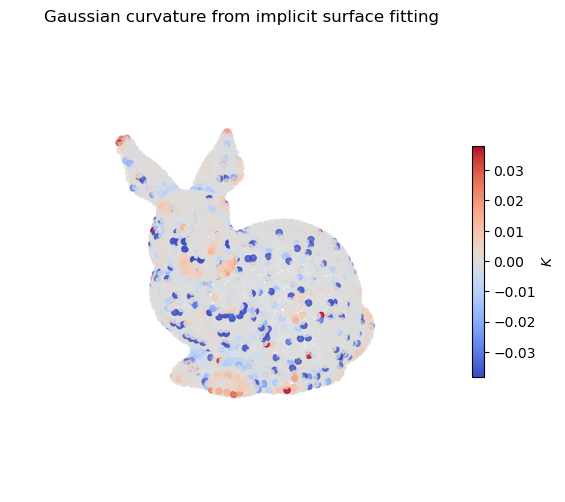

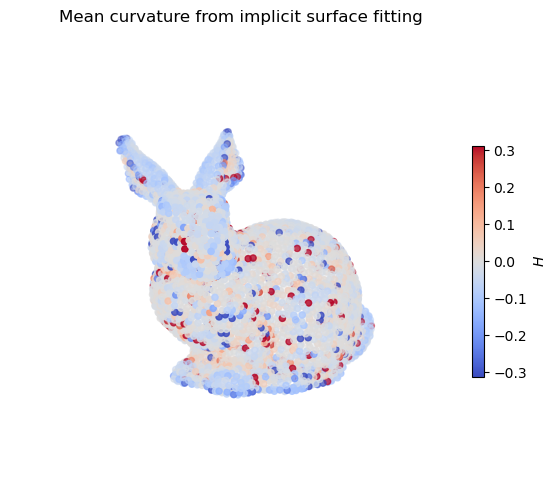

In [13]:
# Compute curvatures using the implicit surface fitting approach
neighbor_finder = lambda points: kdtree.query(points, k=12)[1]
kappa_1_implicit, kappa_2_implicit, normals_implicit = \
    compute_curvature_implicit(points, neighbor_finder)

# Orient with reference normals (alternatively with graph)
orientation = np.sign(
    np.sum(normals_implicit * ref_normals, axis=1)
)
normals_implicit *= orientation[:, None]
kappa_1_implicit *= orientation
kappa_2_implicit *= orientation
K_implicit = kappa_1_implicit * kappa_2_implicit
H_implicit = (kappa_1_implicit + kappa_2_implicit)/2

# Plot mean and Gaussian curvatures
for curvature_type, unit, values in [
        ("Gaussian", "$K$", K_implicit), 
        ("Mean", "$H$", H_implicit)
    ]:
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    p = ax.scatter(points[:, 0], points[:, 1], points[:, 2],
                   c=values, cmap='coolwarm', norm=ref_norms_k[curvature_type])
    cbar = fig.colorbar(p, shrink=0.5, pad=0)
    cbar.set_label(unit)
    ax.set_box_aspect([1, 1, 1])
    ax.set_axis_off()
    ax.view_init(10, 60)
    ax.set_title(f"{curvature_type} curvature from implicit surface fitting")
    plt.show()


### Discrete differential operators

Discrete differential operator methods aim to **adapt smooth differential‑geometry operators directly to pointclouds**, eliminating the need to reconstruct a local smooth surface. The core idea is to approximate operators, such as the shape operator using only local neighborhoods of points, producing curvature estimates without explicit surface fitting. Most discrete differential operators were originally developed for triangle meshes, where connectivity naturally supports discrete analogs of differential geometry. When adapted to pointclouds, mesh connectivity is typically replaced by local neighborhoods defined through $k$-nearest neighbors.

The explanation below focuses on an early influential technique, often referred to as **Taubin’s method**, which **infers curvature from how vertex normals change over local neighborhoods** \cite{taubin1995estimating}.

Taubin's method relies on the *tensor of curvature*, a quadratic form that associates a directional curvature $\kappa(t)$ with every tangent direction $t$. The directional curvature is approximated from neighboring points using the finite-difference expression:

\begin{equation*}
    \kappa(t) \approx \frac{2n \cdot (q - p)}{||q - p||^{2}}
\end{equation*}

where $p$ is the query point, $n$ its normal, and $q$ its neighbor in direction $t$. This quantity measures how far the neighbor deviates from the tangent plane along the considered direction.

Curvature estimates collected from all neighboring directions are then combined to build a symmetric matrix approximating the local curvature tensor, from which the principal curvatures and directions may be recovered. 

**The quality of this approximation depends strongly on how uniformly the neighboring points sample the tangent plane**. Anisotropic neighborhoods can introduce an artificial difference between the principal curvatures, even on surfaces whose curvature is theoretically identical in all directions (e.g., a sphere). Increasing the neighborhood size or using more uniformly distributed samples generally reduces this bias by improving the coverage of tangent directions.

The original algorithm is formulated for triangular meshes, where vertex normals are estimated from the weighted average of incident face normals and curvature tensors are built from edge-based neighborhoods. For pointclouds, the same procedure can be adapted by estimating normals using local tangent‑plane fitting and defining neighborhoods using $k$-nearest neighbors instead of mesh connectivity. An adaptation of the method to pointclouds is summarized below.

For each point $p_{i}$ of the pointcloud with normal $n_{i}$:

1. Query the $k$-nearest neighbors of $p_{i}$ and form the set $N_i$.

2. Approximate the curvature tensor matrix as a weighted sum over neighbors:
\begin{equation*}
    M_{i} = \sum_{p_{j} \in N_i} \omega_{ij} \kappa_{ij} t_{ij} t_{ij}^{T}
\end{equation*}
with projected tangent directions:
\begin{equation*}
    t_{ij} = \frac{(I - n_{i} n_{i}^{T}) \cdot (p_{i} - p_{j})}{\lVert (I - n_{i} n_{i}^{T}) \cdot (p_{i} - p_{j}) \rVert}
\end{equation*}
and directional normal curvature:
\begin{equation*}
    \kappa_{ij} = \frac{2 n_{i} \cdot (p_{j} - p_{i})}{\lVert p_{j} - p_{i} \rVert^{2}}
\end{equation*}
and distance-based weights (or optionally constant weights):
\begin{equation*}
    \omega_{ij} = \frac{\lVert p_{j} - p_{i} \rVert ^{-2}}{\sum_{p_{j} \in N_{i}} \lVert p_{j} - p_{i} \rVert ^{-2}}
\end{equation*}

3. Restrict the curvature tensor approximation to a basis aligned with the tangent plane. This is done using a Householder transformation:
\begin{equation*}
    Q_{i} M_{i} Q_{i}^{T} =
    \begin{pmatrix}
    0 & 0 & 0 \\
    0 & m_{11}^{i} & m_{12}^{i} \\
    0 & m_{21}^{i} & m_{22}^{i}
    \end{pmatrix}
\end{equation*}
with
\begin{equation*}
    Q_{i} = I - 2 w_{i} w_{i}^{T}
    \qquad
    w_{i} = \frac{e_{1} \pm n_{i}}{\lVert e_{1} \pm n_{i} \rVert}
\end{equation*}
where the sign is chosen to maximize the denominator.

4. Diagonalize the resulting $2 \times 2$ tangent-plane block to obtain its eigenvalues and eigenvectors. This can be done using either a standard eigendecomposition or a Givens rotation (as in the original paper):
\begin{equation*}
    R(\theta)^{T} M_{i}^{2 \times 2} R(\theta) = 
    \begin{pmatrix}
    m_{11'}^{i} & 0 \\
    0 & m_{22'}^{i}
    \end{pmatrix}
\end{equation*}
where
\begin{equation*}
    \tan (2 \theta) = \frac{2 m_{12}^{i}}{m_{11}^{i} - m_{22}^{i}}
\end{equation*}

5. Recover $\kappa_{1}^{i}$ and $\kappa_{2}^{i}$ principal curvatures associated with $p_{i}$ as:
\begin{equation*}
    \kappa_{1}^{i} = 3m_{11'}^{i} - m_{22'}^{i} \qquad  \kappa_{2}^{i} = 3m_{22'}^{i} - m_{11'}^{i}
\end{equation*}
The curvature tensor approximation averages directional curvature in such a way that:
\begin{equation*}
    m_{11'}^{i} = \frac{3}{8} \kappa_{1}^{i} + \frac{1}{8}  \kappa_{2}^{i} \qquad  m_{22'}^{i} = \frac{1}{8} \kappa_{1}^{i} + \frac{3}{8}  \kappa_{2}^{i}
\end{equation*}

In practice, **the weighting strategy used to construct the curvature tensor can significantly affect the quality of the estimated principal curvatures**. Uniform weights are simple and faithful to the original formulation, while distance-based weights often reduce the bias caused by irregular point distributions by giving more importance to nearby neighbors. As a result, they generally produce more isotropic curvature estimates and can improve accuracy on non-uniformly sampled pointclouds.

This process is illustrated below. Reference normals (derived from the bunny mesh) are again used to isolate curvature estimation errors from errors introduced during normal estimation. The implementation is partially vectorized and all neighborhoods are queried and extracted simultaneously.

In [14]:
def compute_curvature_taubin(points, normals, neighbor_finder):
    """Compute principal curvatures and directions using Taubin's method."""

    N, _ = points.shape
    kappa_1 = np.empty(N)
    kappa_2 = np.empty(N)

    # Neighborhoods
    inds = neighbor_finder(points) # (N, k)
    neighbors = points[inds] # (N, k, 3)
    neighbors -= points[:, None, :] # center on the query point

    # Unit vector for Householder
    e_1 = np.array([1., 0., 0.])

    for i in range(N):

        # Query normal
        n_i = normals[i]

        # Projection matrix onto the tangent plane at p_i (P = I - n.n^T)
        proj_i = np.eye(3) - np.outer(n_i, n_i)      

        # Curvature tensor matrix
        diffs = neighbors[i, 1:] # remove the point itself from neighbors
        dists2 = np.sum(diffs**2, axis=1)

        # Tangent vectors from neighbors projected onto the tangent plane
        t_ij = diffs @ proj_i
        t_ij /= np.linalg.norm(t_ij, axis=1, keepdims=True) # (check zero-div?)
        # Curvature contribution from neighbors
        kappa_ij = 2 * (diffs @ n_i) / dists2
        # Accumulate curvature contributions
        weights = 1.0 / dists2
        weights /= weights.sum()
        M_i = (((weights * kappa_ij)[:, None]) * t_ij).T @ t_ij

        # Restrict M_i to the tangent plane (2D)
        if n_i[0] < 0:
            w_i = (e_1 - n_i) / np.linalg.norm(e_1 - n_i)
        else:
            w_i = (e_1 + n_i) / np.linalg.norm(e_1 + n_i)
        # Householder projection matrix to restrict to the tangent plane
        Q_i =  np.eye(3) - 2 * np.outer(w_i, w_i)
        # Restrict M_i to the tangent plane
        Mt_i = Q_i @ M_i @ Q_i # Householder matrix is orthogonal and symmetric
        m_11 = Mt_i[1, 1]
        m_12 = Mt_i[1, 2]
        m_22 = Mt_i[2, 2]

        # Diagonalize the restricted curvature tensor
        # (using linalg instead of Givens rotations)
        eigenvalues = np.linalg.eigvalsh([[m_11, m_12], [m_12, m_22]])
        m_11_p, m_22_p = eigenvalues[::-1]

        # Equation 5 from Taubin's paper
        kappas = np.array([3*m_11_p - m_22_p, 3*m_22_p - m_11_p])
        # enforce kappa_1 > kappa_2 convention
        kappa_1[i] = np.max(kappas)
        kappa_2[i] = np.min(kappas)

    return kappa_1, kappa_2

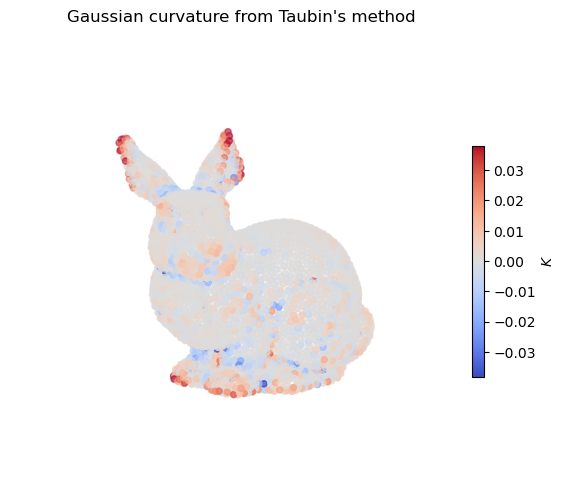

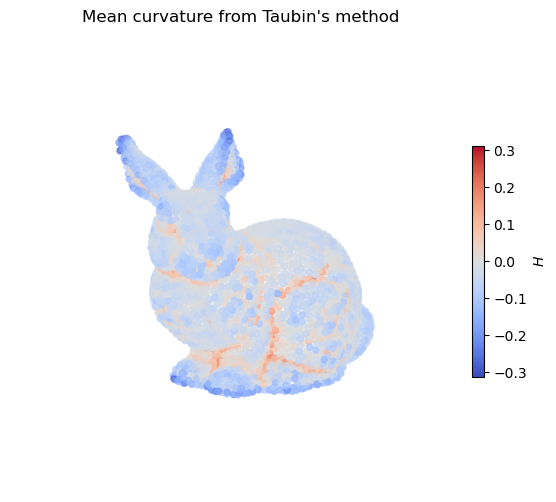

In [15]:
# Compute curvatures using Taubin's method
neighbor_finder = lambda points: kdtree.query(points, k=12)[1]
kappa_1_taubin, kappa_2_taubin = compute_curvature_taubin(
    points,
    ref_normals, # instead of estimated normals
    neighbor_finder
)
# Gaussian and mean curvatures for comparison with previous methods
K_taubin = kappa_1_taubin * kappa_2_taubin
H_taubin = 0.5 * (kappa_1_taubin + kappa_2_taubin)

# Plot mean and Gaussian curvatures
for curvature_type, unit, values in [
        ("Gaussian", "$K$", K_taubin), 
        ("Mean", "$H$", H_taubin)
    ]:
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    p = ax.scatter(points[:, 0], points[:, 1], points[:, 2],
                   c=values, cmap='coolwarm', norm=ref_norms_k[curvature_type])
    cbar = fig.colorbar(p, shrink=0.5, pad=0)
    cbar.set_label(unit)
    ax.set_box_aspect([1, 1, 1])
    ax.set_axis_off()
    ax.view_init(10, 60)
    ax.set_title(f"{curvature_type} curvature from Taubin's method")
    plt.show()


### Quick comparison

Below is a comparison of curvature estimates obtained with parametric fitting, implicit fitting, and Taubin's method, together with reference values computed on the original bunny mesh using a surface fitting approach. All implemented methods produce similar results on this relatively clean and evenly sampled pointcloud.

Parametric fitting formulation matches the differential geometry definition of curvature, is computationally efficient and relatively easy to implement. However, its accuracy depends on a reliable prior normal estimate and and on the validity of the local parameterization. Performance can degrade near steep features, boundaries, or in the presence of significant noise.

Implicit fitting does not require local parameterization, so it can naturally handle arbitrary surface orientations and is generally less sensitive to errors in the estimated tangent frame. This additional flexibility often improves robustness on noisy pointclouds, although at the cost of solving a larger fitting problem.

Rather than fitting a geometric surface, Taubin's method assumes that curvature can be recovered from the variation of normals within a neighborhood. This approach is elegant and computationally efficient once normals are available. However, its accuracy depends directly on the quality of the normal estimates, so noise, normal errors, and irregular sampling can have a stronger impact on the results.

In practice, the differences between the methods become more visible as pointcloud quality decreases. Parametric fitting generally works well on smooth and densely sampled surfaces, implicit fitting is often the most robust to noise and orientation changes, while Taubin's method is attractive for large datasets because of its low computational cost.

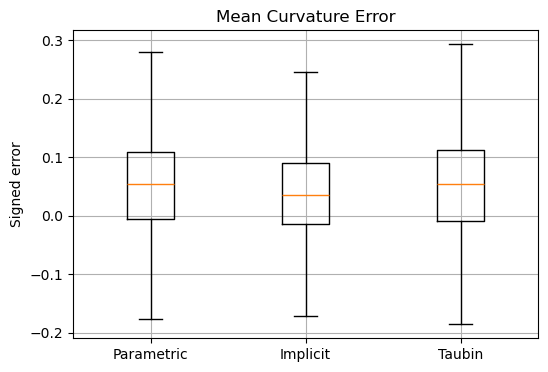

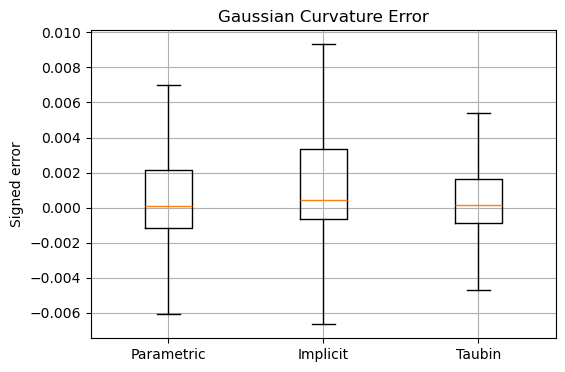

In [16]:
# Estimate angular error between estimated and reference curvatures
for title, ref, estimates in [
    ("Mean Curvature Error", H_ref, [H_parametric, H_implicit, H_taubin]),
    ("Gaussian Curvature Error", K_ref, [K_parametric, K_implicit, K_taubin]),
]:
    error_curvatures = [ref - est for est in estimates]

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.boxplot(
        error_curvatures,
        tick_labels=["Parametric", "Implicit", "Taubin"],
        showfliers=False
    )
    ax.set_ylabel("Signed error")
    ax.set_title(title)
    ax.grid(True)
    plt.show()


## Going further

This section briefly discusses more advanced variants of the techniques detailed earlier for normal estimation, normal orientation, and curvature estimation.

### Normal estimation

Despite being introduced several decades ago, PCA-based tangent-plane fitting remains one of the most widely used techniques for estimating normals in pointclouds. As discussed previously, it assumes that the underlying surface is locally smooth, an assumption that is often violated near sharp features, boundaries, or regions of high curvature.

One important source of error comes from the choice of neighborhood. Standard $k$-nearest-neighbor or spherical neighborhoods are not always well suited to approximate a local tangent plane, particularly in regions with high curvature or close surfaces. The ```orient_normals_consistent_tangent_plane``` implementation of ```open3D``` addresses this issue by using a pseudo-spherical neighborhood that penalizes the distance of neighboring points to the tangent plane and optionally rejects neighbors whose normals deviate excessively from the local surface orientation. However, this approach requires an initial normal estimate of sufficient quality. Other strategies include adapting the neighborhood size to the local surface curvature and noise level \cite{mitra2003estimating}, or or weighting neighbors according to their distance from the query point.

Another way to improve normal estimation is to fit more expressive local surface models, such as spheres, quadrics, or higher-order polynomial patches. One notable example is *jet fitting* \cite{cazals2005estimating}, implemented for example in ```CGAL``` through ```jet_estimate_normals```. Another influential family of techniques relies on *Moving Least Squares* (MLS) surface reconstruction \cite{alexa2003computing}. These approaches generally capture surface variations more accurately than a planar model, but they also introduce additional parameters and may become more sensitive to noise.

Surface fitting is not the only approach to normal estimation. Alternatives rely on RANSAC, Voronoi-based constructions, or Hough-transform techniques. A notable example combines a Hough-transform accumulator with convolutional neural networks to improve robustness to sharp edges, density variations, noise, and outliers \cite{boulch2012fast}. The implementation is open-source and available in CloudCompare through the `HoughNormals` plug-in. Such alternatives often improve robustness at the expense of computational efficiency. More recently, deep-learning approaches have emerged, driven by the availability of large-scale datasets and benchmarks.


### Normal orientation

Obtaining a consistent orientation is often more challenging than estimating the normal directions themselves. The most widely used orientation algorithms propagate orientation across local neighborhoods under the assumption that neighboring tangent planes are nearly parallel, which is equivalent to assuming low local curvature.

To reduce the impact of this assumption, several variants modify the edge-weighting functions and flipping criteria used during propagation. One such approach assumes locally constant curvature, effectively treating neighboring points as lying on a sphere rather than on parallel planes, and replaces the incident normal $n_{i}$ by its reflection $n'_{i}$ across the bisector plane of the segment $e{ij} = p_{i} - p_{j}$ \cite{xie2003piecewise}. This modification preserves most of the original algorithm while improving robustness in regions of high curvature. This is not the case with some other proposed techniques, which rely on more complex edge weighting functions and flip criteria, whose often modest improvements come with higher implementation and computational costs.

Another family of approaches formulates orientation as a propagation problem on a spatial grid. For example, CloudCompare implements a Fast Marching strategy through the `Orient Normals With Fast Marching` tool. These methods are extremely fast and scale well to large pointclouds, but their accuracy depends strongly on the chosen grid resolution.

Alternative strategies rely on additional information, such as scanner positions, visibility constraints, or surface reconstruction techniques. More recently, deep-learning approaches have emerged, and now provide state-of-the-art results on several normal-orientation tasks.


### Curvatures

Curvature estimation from 3D pointclouds is particularly challenging because differential-geometric quantities are defined on smooth surfaces, whereas pointclouds provide only a discrete sampling of the geometry. As a result, many workflows rely on simple curvature proxies, such as *PCA-based surface variation*, rather than attempting to estimate full principal curvatures.

Local surface fitting remains one of the most widely adopted strategies for estimating point‑wise curvatures. The simplest models approximate the local geometry using parametric or implicit quadrics, while higher-order approaches such as *jet fitting* \cite{cazals2005estimating} extend this idea with richer polynomial models. A reference implementation is for example available in ```CGAL``` through ```Monge_via_jet_fitting```. Robustness can also be improved by incorporating normal information directly into the fitting process, reducing sensitivity to noise and irregular sampling \cite{goldfeather2004novel}.

Another influential family of approaches is based on *Moving Least Squares* (MLS) surfaces \cite{alexa2003computing}. Rather than fitting an independent surface to each neighborhood, MLS constructs a smooth surface approximation from weighted local polynomial regressions. This often improves robustness to noise and has become a standard tool in pointcloud processing pipelines. Implementations are available in libraries such as `PCL` and `CGAL`.

Discrete differential operators are less commonly applied directly to raw pointclouds, as they were originally developed for triangle meshes where connectivity supports discrete analogues of smooth operators. Some techniques can be adapted to pointclouds using only nearest‑neighbor information. For example, ```PrincipalCurvaturesEstimation``` found in ```PCL``` computes curvatures by projecting neighbor normals into the tangent plane and applying PCA. In the general case, many discrete curvature estimators still require constructing a mesh as an intermediate representation. Once a mesh is available, a broad range of tools from discrete differential geometry become accessible, including angle-defect Gaussian curvature, cotangent-Laplacian mean curvature, normal-cycles estimators, and numerous other operators developed for mesh processing.

## Wrapping up

You should now have a clearer understanding of how to extract meaningful local geometric information from pointclouds through the estimation of normals and curvatures. These quantities form the foundation of many geometry-processing algorithms. Normals describe the local surface orientation, while curvatures quantify how the surface bends, providing a richer description of the underlying shape.

**Normals are most commonly estimated through local plane fitting using** Principal Component Analysis (PCA), which simultaneously provides a tangent plane and its least-squares normal direction. Because these normals are initially unoriented, a second step is required to ensure consistency across the pointcloud, typically through graph-based orientation propagation. Curvature estimation often builds upon these local reference frames. Common approaches range from PCA-based descriptors such as *surface variation*, which measures the deviation of points from the local tangent plane, to **local surface fitting techniques that recover principal, mean, and Gaussian curvatures by approximating the geometry with smooth second-order surfaces**.

The next notebook focuses on task‑oriented descriptors, or *features*, that are not intrinsic surface properties, but higher level representations designed to capture patterns relevant to matching, retrieval, or learning‑based tasks. These representations bridge the gap between low‑level geometry and high‑level reasoning, enabling more powerful analysis of 3D data.
